# Singular spectrum analysis, reconstruction, significance, and forecasting

This notebook provides another opportunity to practice singular spectrum analysis.  At the end of the notebook, there is an example of how to use SSA for forecasting (semi-) cyclical behavior.  We'll use the [airline passenger dataset](https://www.wiley.com/en-sg/Time+Series+Analysis%3A+Forecasting+and+Control%2C+5th+Edition-p-9781118675021) I've shown in class a few times.  The data has several different structures -- an annual cycle, semi-annual features, a long-term trend, and a change in cyclical amplitudes -- which make it an interested target for potential extracting these modes from the time series. 

In [181]:
import math
import numpy as np
import pandas as pd
import xarray as xr
import scipy as sp

from scipy.signal import periodogram 

import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from matplotlib.dates import DateFormatter

# nicely render figures in the notebook 
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

# you can omit the line below if you'd like, but I really don't like the default fonts in Python, so I switch to Helvetica
plt.rcParams['font.family'] = 'Helvetica'


Get the airline passenger data and do a quick sanity check to make sure it looks right:

<Axes: xlabel='Time'>

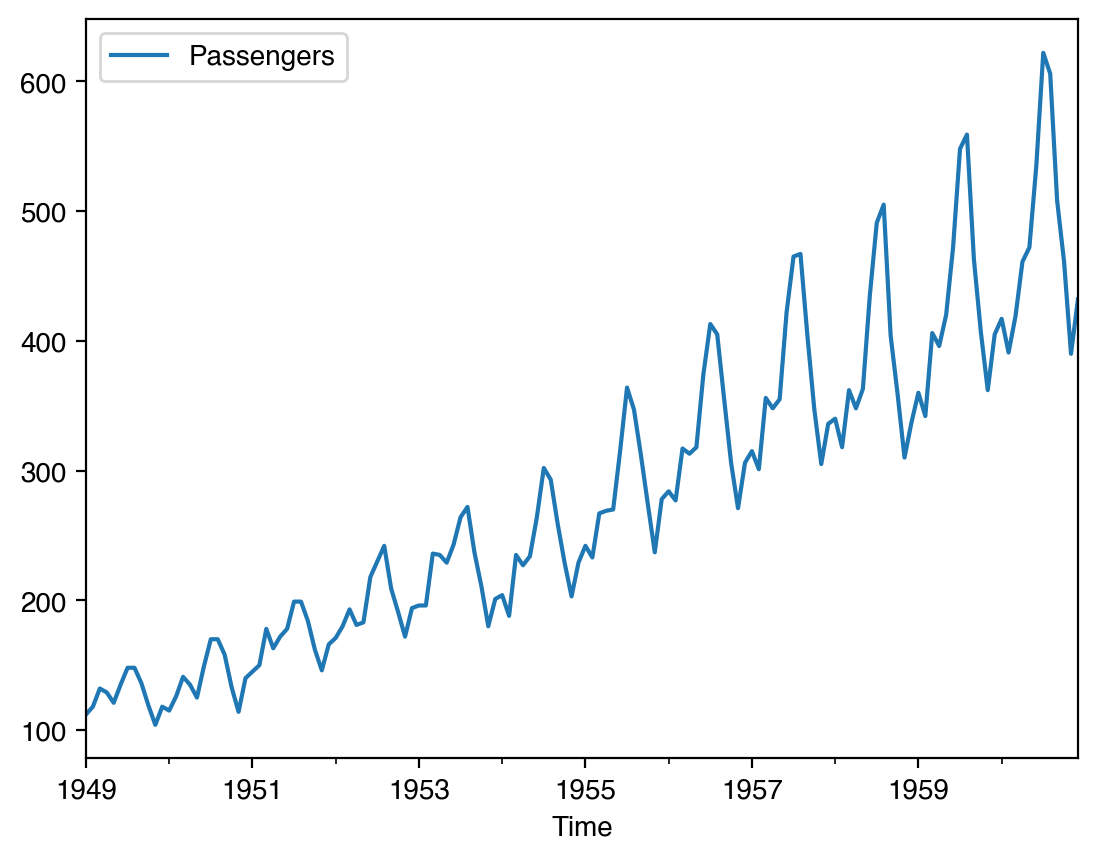

In [182]:
data = pd.read_csv("AirPassengers.csv",parse_dates=True,index_col="Time")
data.plot()

Visually you can see an annual cycle with some structure (e.g. which months are the 'peaks' in air travel?) We can calculate the mean annual cycle to better understand the structure over the course of a year.  We can also generate abbreviated month names for the plot by accessing Pandas' datetime functions using the $.dt$ notation (https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html) - when a Pandas series contains a datetime object (as the Passenger Data does), this allows us to access parts of those datatime objects directly. 

Text(0.5, 1.0, 'MEAN ANNUAL CYCLE OF AIRLINE PASSENGERS')

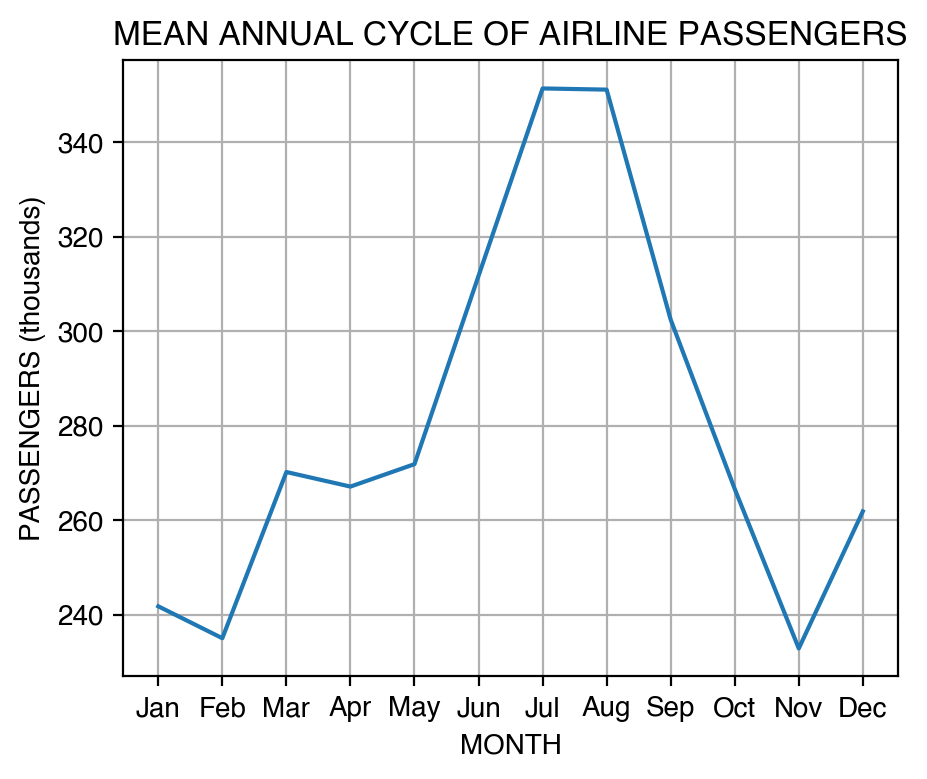

In [ ]:
monthly = data.groupby(data.index.month).mean() # group the data by months and take a mean
monthly.index = pd.to_datetime(monthly.index, format='%m').strftime('%b') # create a monthly index (names of the months) for plotting the annual cycle - uses strftime from Pandas: https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.strftime.html

# create the figure
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(monthly)
ax.grid()
ax.set_xlabel('MONTH')
ax.set_ylabel("PASSENGERS (thousands)") # units from the original data plot
ax.set_title("MEAN ANNUAL CYCLE OF AIRLINE PASSENGERS")


As you can see, the peaks are in March (Easter? Spring Break?), summer, and December (winter holidays?).

Use `.values.flatten()` to get just the time series out of the Pandas DataFrame so we can operate on them like an array:

In [184]:
ts = data.values.flatten() # operate on just the data in the time series now, leaving the index behind

We now construct the trajectory matrix:

In [185]:
## remove the mean value as we've been taught, or not? Is there any sensitivity to this choice later? 
# tsbar = np.mean(ts)
# ts = ts-tsbar 

# record the length of the time series for later
N = len(ts)

# select the embedding dimension
M = 30  

# Create an empty trajectory matrix to fill
D = np.empty((M, N - M + 1)) 

# fill the trajectory matrix, see Ghil et al. 2022, equation 5 and equation 6
for i in range(M):
    D[i, :] = ts[i:N - M + 1 + i]
    
D.shape # dimensions are M x N-M+1 as expected


(30, 115)

We then calculate the covariance of the trajectory matrix.  There are actually several ways to do this, but the difference in the cases below is all in the normalization:

In [186]:
## various approaches to the covariance of the trajectory matrix

# Calculate the covariance matrix from the trajectory matrix, see Ghil et al. 2002, equations 6 and 7
C = np.cov(D,ddof=1) # simple covariance, in this case, the row-based default of numpy's covariance calculation is correct

# no normalization at all - just the matrix product of the trajectory matrix
# C = D @ D.T 

# see Ghil et al. 2002, equations 9, following Broomhead and King - changes the normalization but covariance structure is intact
# C = 1/(M-N+1) * (D @ D.T)

Once we have the covariance matrix, $C$, we can do the singular value decomposition as we have before, and calculate the PCs and the RCs from the resulting eigenvectors:

In [187]:
# Calculate the singular value decomposition of the M by M covariance matrix, see Ghil et al. 2002, equations 8 and 9
U, S, Vt = np.linalg.svd(C,full_matrices=True)

# Get eigenvalues and calculate the percent variance explained
eval = S
varexp = 100 * (eval / np.sum(eval))

# Form the signals (PCs) as the matrix A following Ghil et al. 2002, equation 10
A = U.T @ D  # Note that you're multiplying the eigenvectors with the trajectory (not the data!) matrix

# Initialize Reconstructed Components (RC) matrix
RC = np.empty((M, N))

# Calculate the Reconstructed Components, see Ghil et al. 2002, equation 11 (and equation 52)
for i in range(M):
    RC[i, :] = np.convolve(U[:, i], A[i, :],)[:N]  

# Apply normalization, see Ghil et al. 2002, equation 12
for i in range(N):  
    if 0 <= i < M:  # ad hoc adjusted for zero-based indexing
        RC[:, i] *= 1 / (i + 1)  
    elif M - 1 <= i < N - M + 1:  
        RC[:, i] /= M
    else:
        RC[:, i] /= (N - i)  
        
# we might also calculate North's Rule of Thumb here as Ghil et al. do - see discussion in the caption of Ghil et al. 2002, Figure 3
def northTest(ev, neff):
    
    error_factor = np.sqrt(2.0 / neff) # the square root scaling using the effective degrees of freedom
    error_range = error_factor * ev # apply the square root scaling to the eigenvalues 
	
    return (error_range) # return the error ranges
        
# pass the eigenvalues as input and use Ghil et al.'s effective N calculation from the caption of their Figure 3
ar1 = np.corrcoef(ts[:-1], ts[1:])[1,0] # simple lag-1 autocorrelation
tau = -(1/math.log(ar1)) # from Ghil et al. 2002, Figure 3
neff = len(ts)/(tau * 1.5) # from Ghil et al. 2002, Figure 3

north_errors = northTest(eval,neff)

Let's plot the eigenvalues by their rank:

Text(0.5, 0, 'EIGENVALUE RANK')

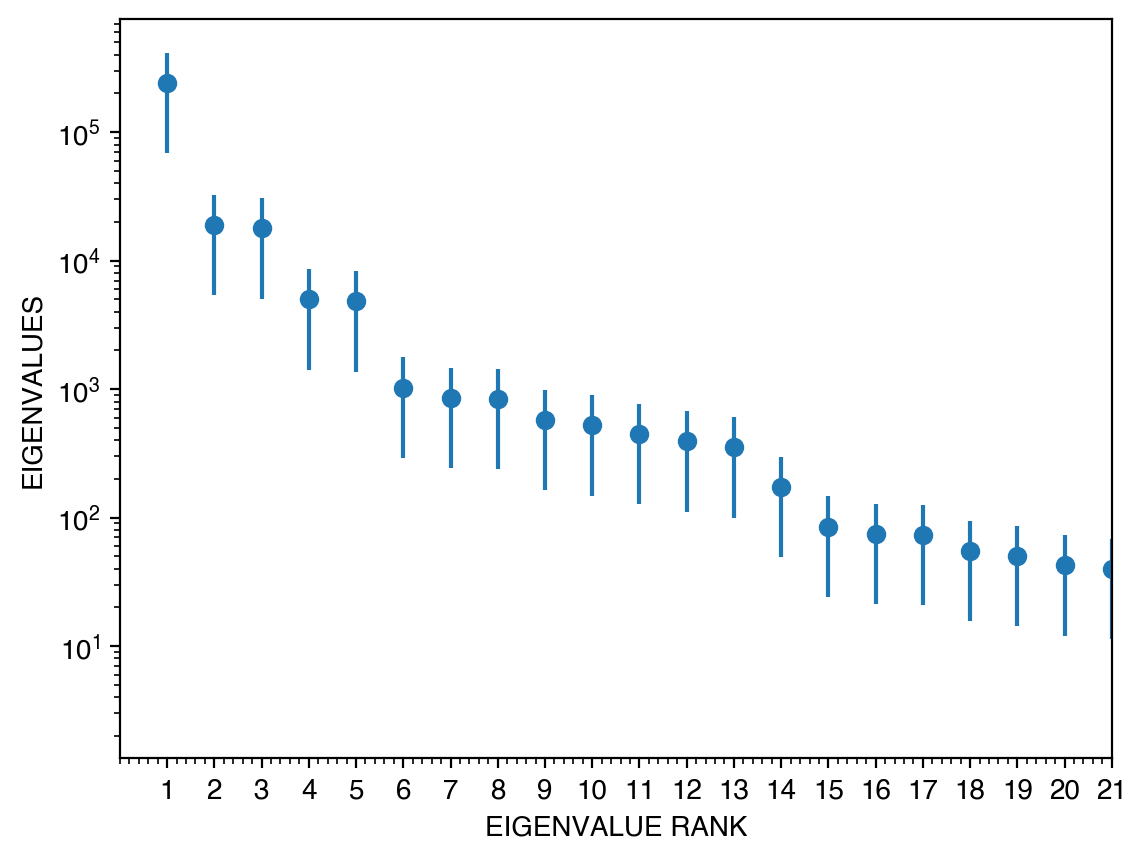

In [188]:
plt.errorbar(np.arange(1,len(eval)+1),eval,yerr=north_errors,linestyle="none",marker="o") # log scale will make error bars look asymetrical 
plt.xlim(0,21)
plt.yscale("log") # you'll see more detail in log space, otherwise the first mode is dominated by the trend variance
plt.minorticks_on()
plt.xticks(np.arange(1,22));
plt.ylabel("EIGENVALUES")
plt.xlabel("EIGENVALUE RANK")

We now plot the first several eigenvectors and observe their shape and periodicities:

Text(0.5, 0, 'LAG (MONTHS)')

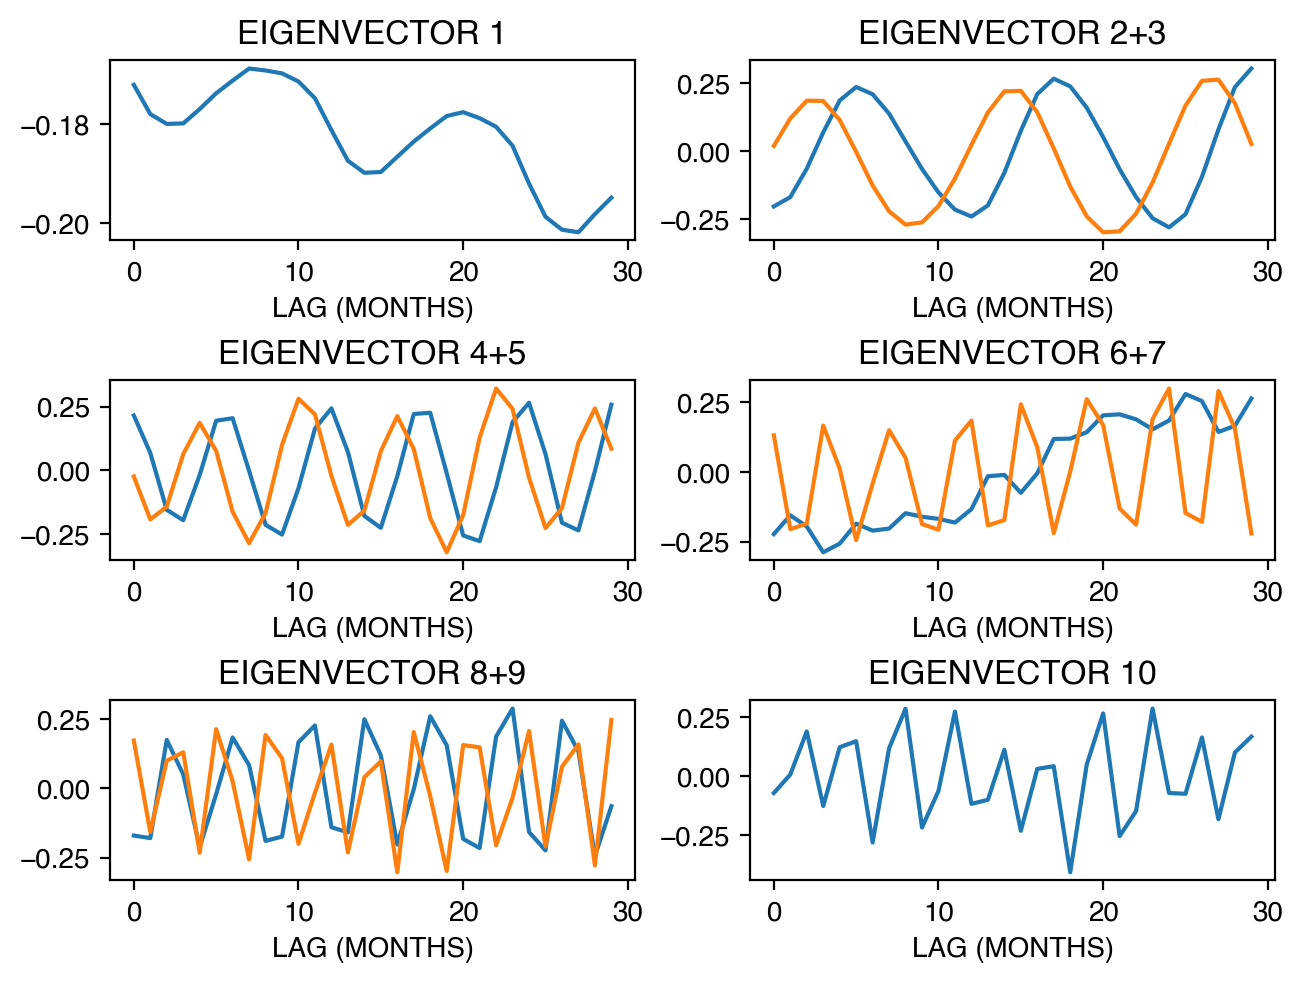

In [189]:
fig, axs = plt.subplots(clear=True,nrows=3,ncols=2,layout="constrained")

axs[0,0].plot(U[:,[0]])
axs[0,0].set_title("EIGENVECTOR 1")
axs[0,0].set_xlabel('LAG (MONTHS)')

axs[0,1].plot(U[:,[1,2]])
axs[0,1].set_title("EIGENVECTOR 2+3")
axs[0,1].set_xlabel('LAG (MONTHS)')

axs[1,0].plot(U[:,[3,4]])
axs[1,0].set_title("EIGENVECTOR 4+5")
axs[1,0].set_xlabel('LAG (MONTHS)')

axs[1,1].plot(U[:,[5,6]])
axs[1,1].set_title("EIGENVECTOR 6+7")
axs[1,1].set_xlabel('LAG (MONTHS)')

axs[2,0].plot(U[:,[7,8]])
axs[2,0].set_title("EIGENVECTOR 8+9")
axs[2,0].set_xlabel('LAG (MONTHS)')

axs[2,1].plot(U[:,[9]])
axs[2,1].set_title("EIGENVECTOR 10")
axs[2,1].set_xlabel('LAG (MONTHS)')

We can compute the spectra for each mode as well - here I'll use the RCs to do this.  We'll also estimate the periodicity with the maximum power in each spectra at the same time:

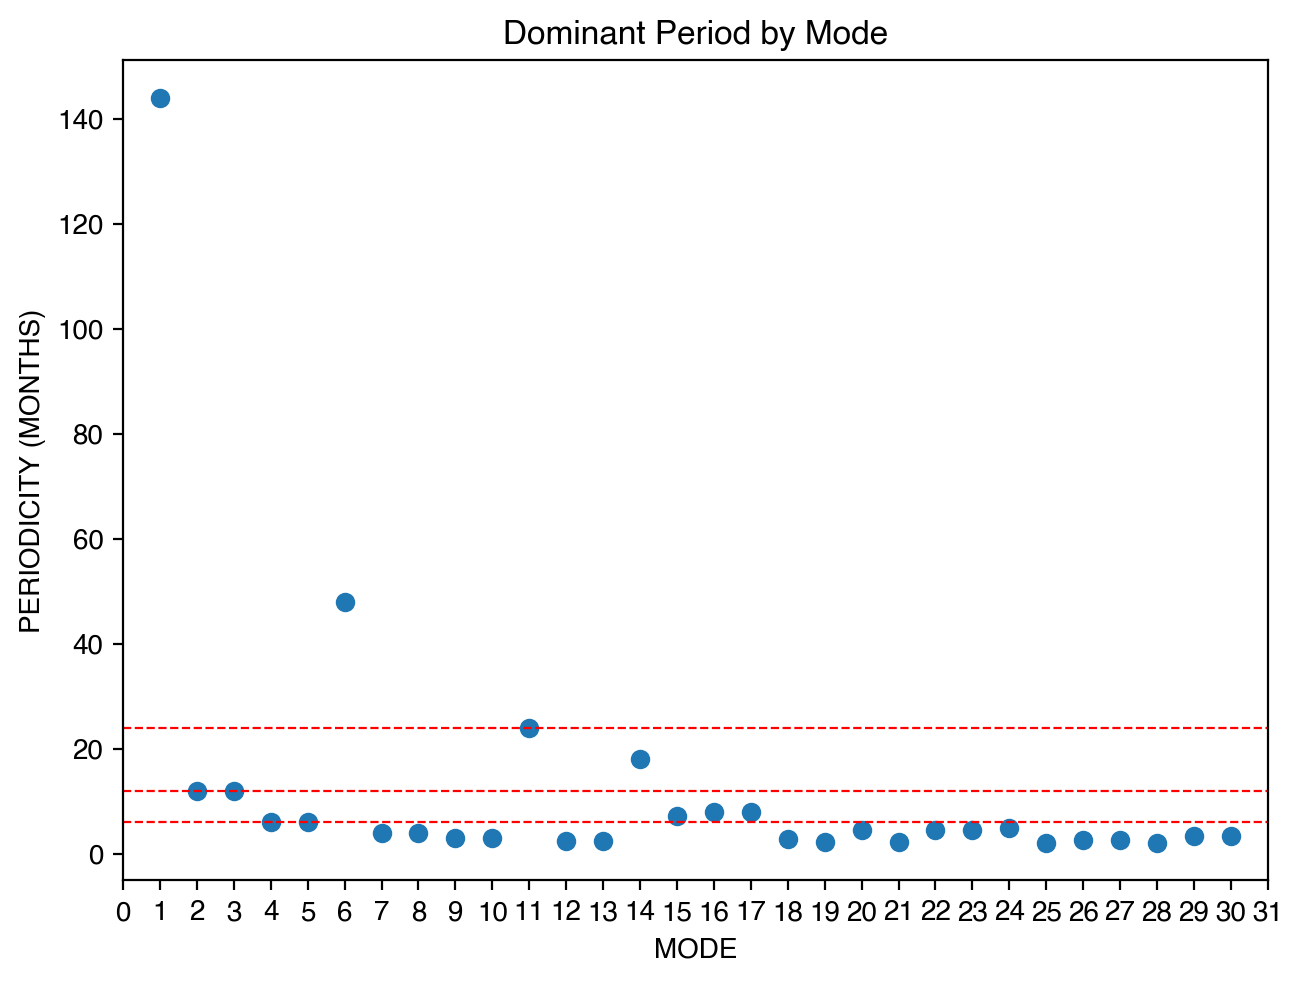

In [190]:
def compute_spectra(RC):
    spectra = [] 
    max_periods = np.full(RC.shape[0], np.nan) # pre-allocate from unput

    for idx, row in enumerate(RC): # for each row of RC containing the RCs ...
        f, Pxx = periodogram(row) # calculate the periodogram

        # find dominant period but skip index position 0 (f=0, or infinite period)
        max_idx = np.argmax(Pxx[1:]) + 1      # ignore DC bin
        max_periods[idx] = 1 / f[max_idx]     # assumes period is in months - 

        spectra.append((f[1:], Pxx[1:]))       # drop f=0, infinte period, for plotting

    return spectra, max_periods

# call the function above
spectra, max_periods = compute_spectra(RC)

# for plotting and labeling the mode numbers
modes = np.arange(1, RC.shape[0] + 1)

# make the plot
fig2, ax2 = plt.subplots(layout="constrained")
ax2.plot(modes, max_periods, marker="o", linestyle="none")  
ax2.set_xlim(0, len(modes) + 1)
ax2.set_xticks(np.arange(0, len(modes) + 2))
ax2.set_xlabel("MODE")
ax2.set_ylabel("PERIODICITY (MONTHS)")
ax2.set_title("Dominant Period by Mode")
ax2.axhline(6,  color='red', linestyle='--', linewidth=0.8) # dashed red line at 6 months
ax2.axhline(12,  color='red', linestyle='--', linewidth=0.8) # dashed red line at 12 months
ax2.axhline(24, color='red', linestyle='--', linewidth=0.8) # dashed red line at 24 months

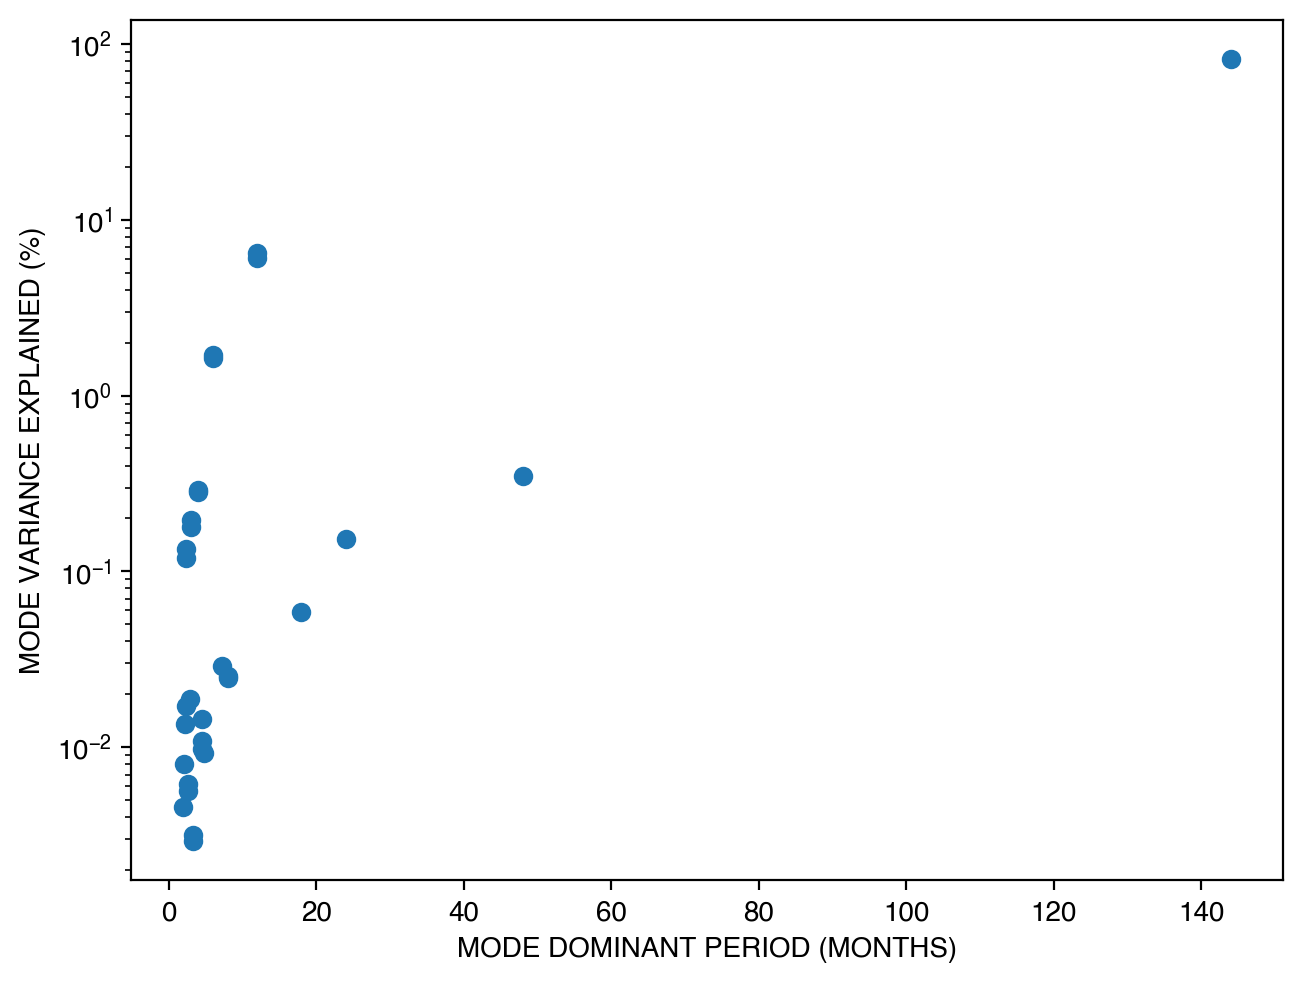

In [191]:
fig3, ax3 = plt.subplots(layout="constrained")
ax3.plot(max_periods, varexp, marker='o', linestyle='none')
ax3.set_xlabel("MODE DOMINANT PERIOD (MONTHS)")
ax3.set_ylabel("MODE VARIANCE EXPLAINED (%)")
ax3.set_yscale('log')

Text(0, 0.5, 'INDEX')

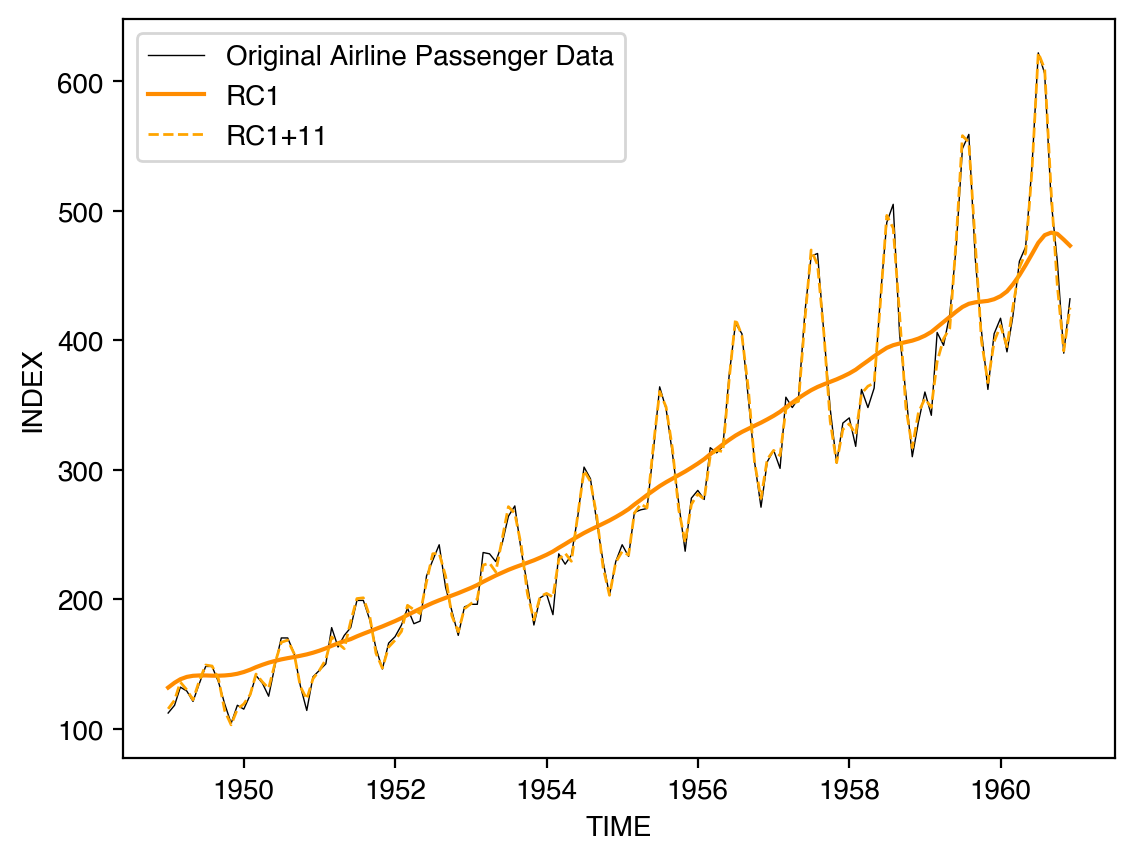

In [192]:
includeModes = 11 # test how many modes needed for the key features?

plt.plot(data.index,ts,color="k",linewidth=0.5,label="Original Airline Passenger Data") # get time dimension from the original Pandas DataFrame!
plt.plot(data.index,RC[0,:],color="darkorange",linewidth=1.5,linestyle="-",label="RC1")
plt.plot(data.index,np.sum(RC[0:includeModes,:],axis=0),color="orange",linewidth=1,linestyle="--",label="RC1+"+str(includeModes))
plt.legend()
plt.xlabel("TIME")
plt.ylabel("INDEX")

## Monte Carlo Significance Testing


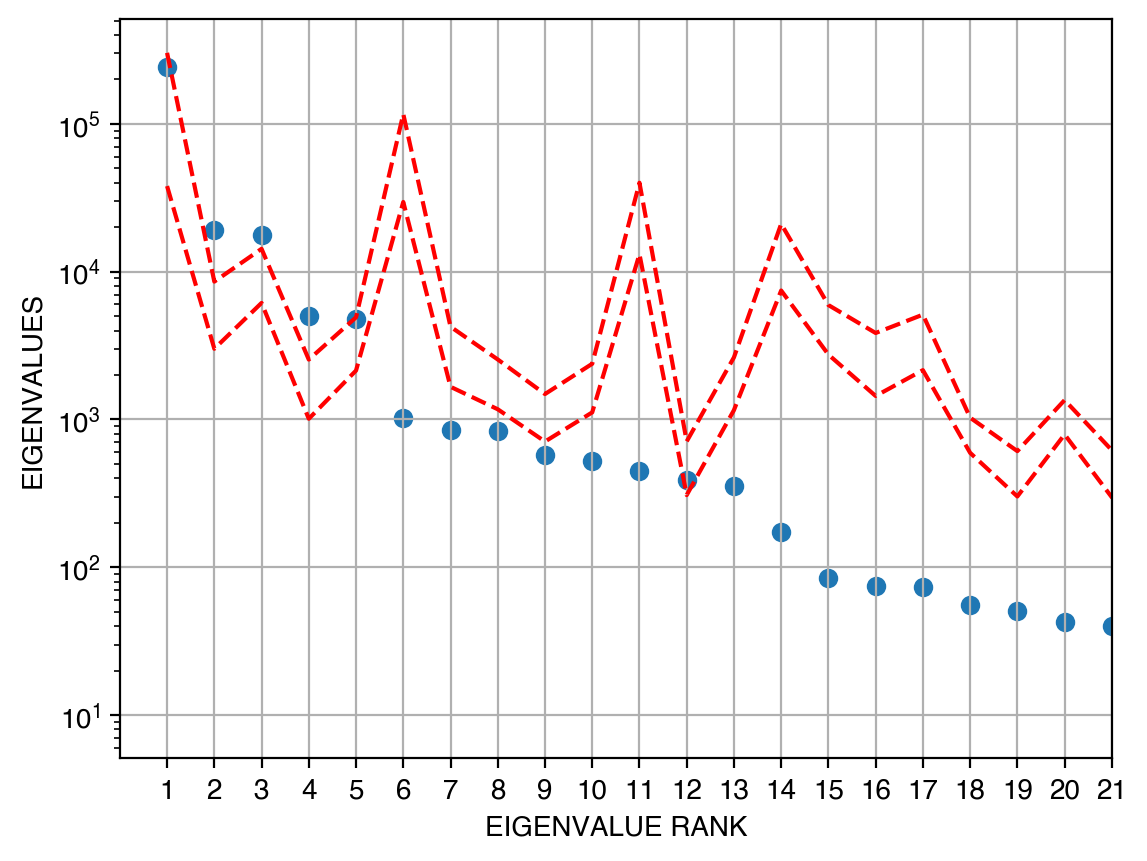

In [193]:
iterations = 10000

# parameters of the time series
mu    = np.mean(ts)
x     = ts - mu # we'll temporarily remove the mean to calculate the time series parameters
g0    = np.dot(x, x) / (N-1) # the variance of the time series
g1    = np.dot(x[:-1], x[1:]) / (N - 1)  # lag-1 autocovariance
alpha = g1 / g0 # estimated AR(1) coefficient 
sigma2 = g0 * (1.0 - alpha**2) # variance from the Yule-Walker approach 
sigma  = np.sqrt(sigma2) # standard deviation

# pre-allocate
lambda_red = np.empty((iterations, M))

# loop over iterations, make the red noise, trajectory matrix, and covariance matix, then project red noise covariance matrix on the real eigenvectors
for k in range(iterations):

    # generate a surrogate time series of length N 
    noise = np.random.normal(0, sigma, N)
    surrogate = np.empty(N)
    surrogate[0] = noise[0]
    for t in range(1, N):
        surrogate[t] = alpha * surrogate[t - 1] + noise[t]
    
    # surrogate += mu  # restore the mean

    # build the surrogate's trajectory matrix the same way we did above
    D_s = np.empty((M, N-M+1))
    for i in range(M):
        D_s[i, :] = surrogate[i : N - M + 1 + i]

    # compute surrogate's covariance matrix the same way we did above
    C_s = np.cov(D_s, ddof=1)

    # project this C_s onto the real data eigenvectors U, following Allen and Smith 1996, their equation 6
    lambda_s = U.T @ C_s @ U

    # diagonal elements are the surrogate's eigenvalues from the diagonal of S
    lambda_red[k, :] = np.diag(lambda_s)
    
confidence_intervals = np.percentile(lambda_red,[10,90], axis=0)
p5, p95 = confidence_intervals  # unpack the 3 rows

# mode numbers for plotting
modes = np.arange(1, M + 1)

# simple plot with 10 and 90% confidence limits shown
plt.scatter(modes,eval) 
plt.plot(modes, p5, 'r--')
plt.plot(modes, p95, 'r--')
plt.yscale("log") # you'll see more detail in log space
plt.xticks(np.arange(1,22));
plt.ylabel("EIGENVALUES")
plt.xlabel("EIGENVALUE RANK")
plt.xlim(0,21)
plt.grid()


Huh, that's weird looking.  We see that the leading mode (the trend in the airline data) is marginally or not significant even at the generous 90% level, that modes 2, 3, 4, and perhaps 5 are above the confidence limit, but that nearly all the other modes have eigenvalues below the 5% confidence limit (or, that these modes explain *less* variance than you would expect even from a simple AR1 noise process).  

My interpretation of this is simply that the AR1 null model we used isn't a good one for this particular data.  The dominance of the seasonal cycle leads the leading modes to capture a very large amount of the variance, particularly as we saw above in the 6 and 12 month periods.  Because the red noise null series are set to have the same variance as the real data, but we have not require such a strong seasonal cycle, the real eigenvalue trace is dominated by these strongly cyclical modes while the simple AR1 red noise model is not.  This creates the mismatch in the null vs. data eigenvalue trace.  This is an example of why the selection of the null model ('what are we afraid of, besides clowns?') is so important.  In the case of the airline passenger data, we would need a better strategy for determining 'significant' modes - we could remove the seasonal cycle beforehand (although there is also an amplitude change over time, so this would not entirely work), or we could use a null model that can produce seasonal behavior (like a SARIMA model), or we could take a different approach and do some sort of block or phase randomization (Pyleoclim has a method for phase randomization used for testing correlation significance, see: https://pyleoclim-util.readthedocs.io/en/latest/utils/introduction.html#pyleoclim.utils.tsutils.phaseran).

Once again, this emphasizes that when we think of 'significance', there is no single way to understand this concept -- we have to be aware of the potential for Type I and Type II errors, we have to try and select appropriate null models, and we have to think like scientists, not statistical robots. 

### Extra: Forecasting

Because the SSA provides the eigenvector patterns (as a function of wavelenths) and reconstructed components (as a function of time), we can actually use SSA to forecast the future of a time series (with the rather strict assumption that the oscillatory modes remain the same).  The method below is based on [Ghodsi et al. 2018](https://doi.org/10.1080/02664763.2017.1401050), using the eigenvectors and RCs to make a forecast in time.  Essentially, we are trying to forecast each new (future) value as a weighted sum of the previous values, using the embedding dimension $M$ to set the number of previous values use in the forecast. 

Several of the SSA steps above, as well as the parameters in the forecasting approach below, have important influences on the forecast - try them out and see for yourself:

Text(0.5, 0, 'TIME STEP (months))')

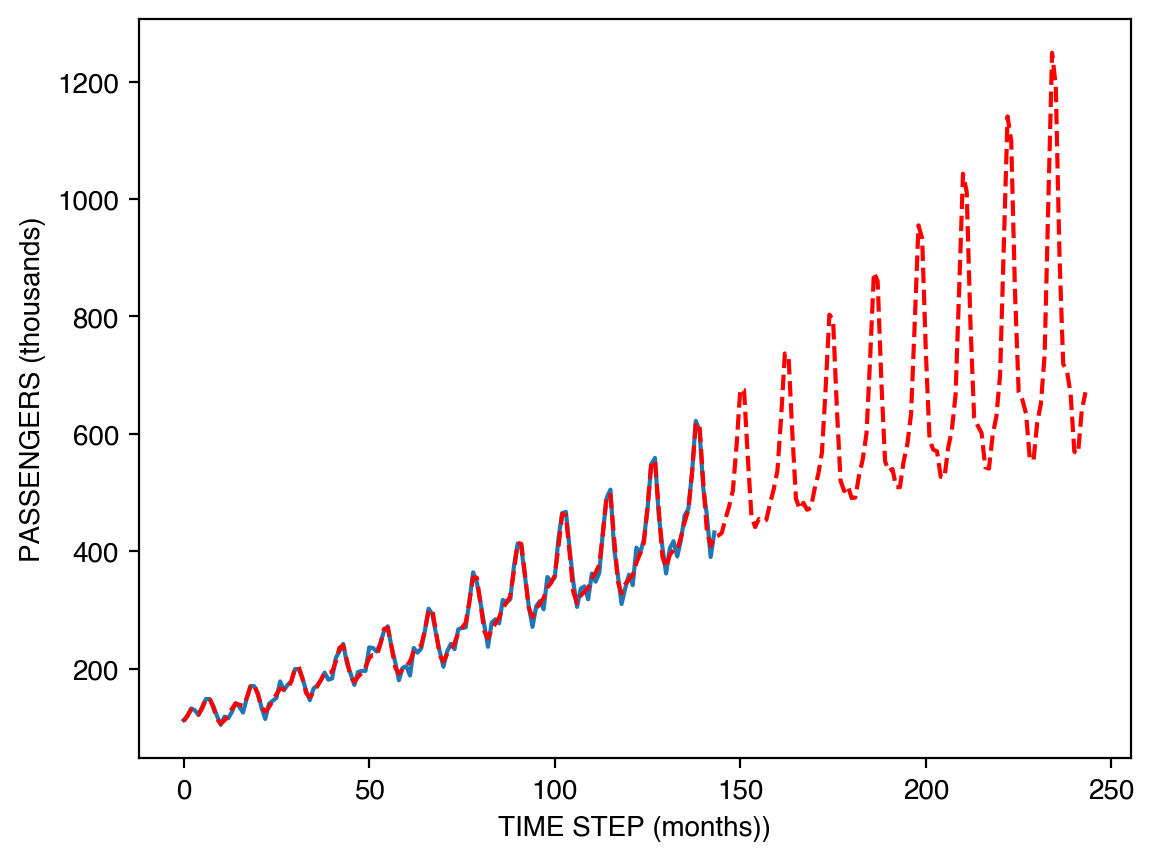

In [ ]:
fN = 8 # how many modes to use for the forecasting? Significance test? Sensitivity test? What do you think? 
fP = 100 # forward time steps to predict - how many time steps forward might be realistic or valid? 

# from above, we have:
# N - the length of the input time series 
# M - the embedding dimension of the singular spectrum analysis (from code above)
# U - the eigenvectors of trajectory matrix X (from code above)
# RC - the Reconstructed Components from the SSA (from code above)

# here, we have: 
# fN - number of reconstructed components to be used for the forecast (set in the lines immediately above)
# fP - number of points to be forecasted (set in the lines immediately above)
# Ax - coefficients (linear recurrence coefficients) that describe the repeated patterns represented by the selected SSA eigenvectors
# F - output of the forecast, the sum of the first fN reconstructed components from SSA plus fP points forecasted via Ax and the fN first reconstructed components

# initialize Ax -- the coefficients for the forecast -- as an array of zeros
Ax = np.zeros(M-1)

# below follows Ghodsi et al. 2018, Section 2 and specifically Section 2.1
# accumulate the outer product of the last entry of each of the first fN eigenvectors with the remaining part of the same eigenvector
for i in range(fN):  # for i = 0, 1, ..., fN-1
    Ax += U[-1, i] * U[:M-1, i] # essentially, given the end value of an eigenvector, what did the time series associate with that mode do over the previous (M-1) values?

# calculate the norm of the last element of the first fN eigenvectors to use for normalization, see Ghodsi et al. 2018, Section 2.1 
v = np.linalg.norm(U[-1, :fN]) 

# normalize Ax by (1-v^2), which is a scaling to account for the fact that we are not using all the eigenvectors, so we only have a portion of the original variance from the time series
Ax /= (1 - v**2) # see Ghodsi et al. 2018, Section 2.1 

# reverse the elements in Ax - these are now forecasting coefficients 
Ax = Ax[::-1]

# sum the first fN RCs - these are our 'reduced space' observations from which we'll then forecast 
G = np.sum(RC[:fN,], axis=0) 

# pre-allocate the forecast (forward) array with the reconstructed observations from G above and then fP zeros where the forecast will go
F = np.concatenate((G, np.zeros(fP))) # this will be length N plus fP

# forecast the next fP points
for i in range(N, N + fP): # Loop over all the desired forecast points 
    for j in range(1, M):  # Loop over all the individual coefficients in Ax 
        F[i] += Ax[j-1] * F[i-j] # forecast the next point from the coefficients and the previous points

# make a quick figure
fig, ax = plt.subplots()
ax.plot(ts)
ax.plot(F, color="red", linestyle="--")
ax.set_ylabel("PASSENGERS (thousands)") # units from the original data plot
ax.set_xlabel("TIME STEP (months))") # units from the original data plot
